In [1]:
from google.colab import files

uploaded = files.upload()  # Select car_data.csv from your computer

Saving 1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv to 1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv


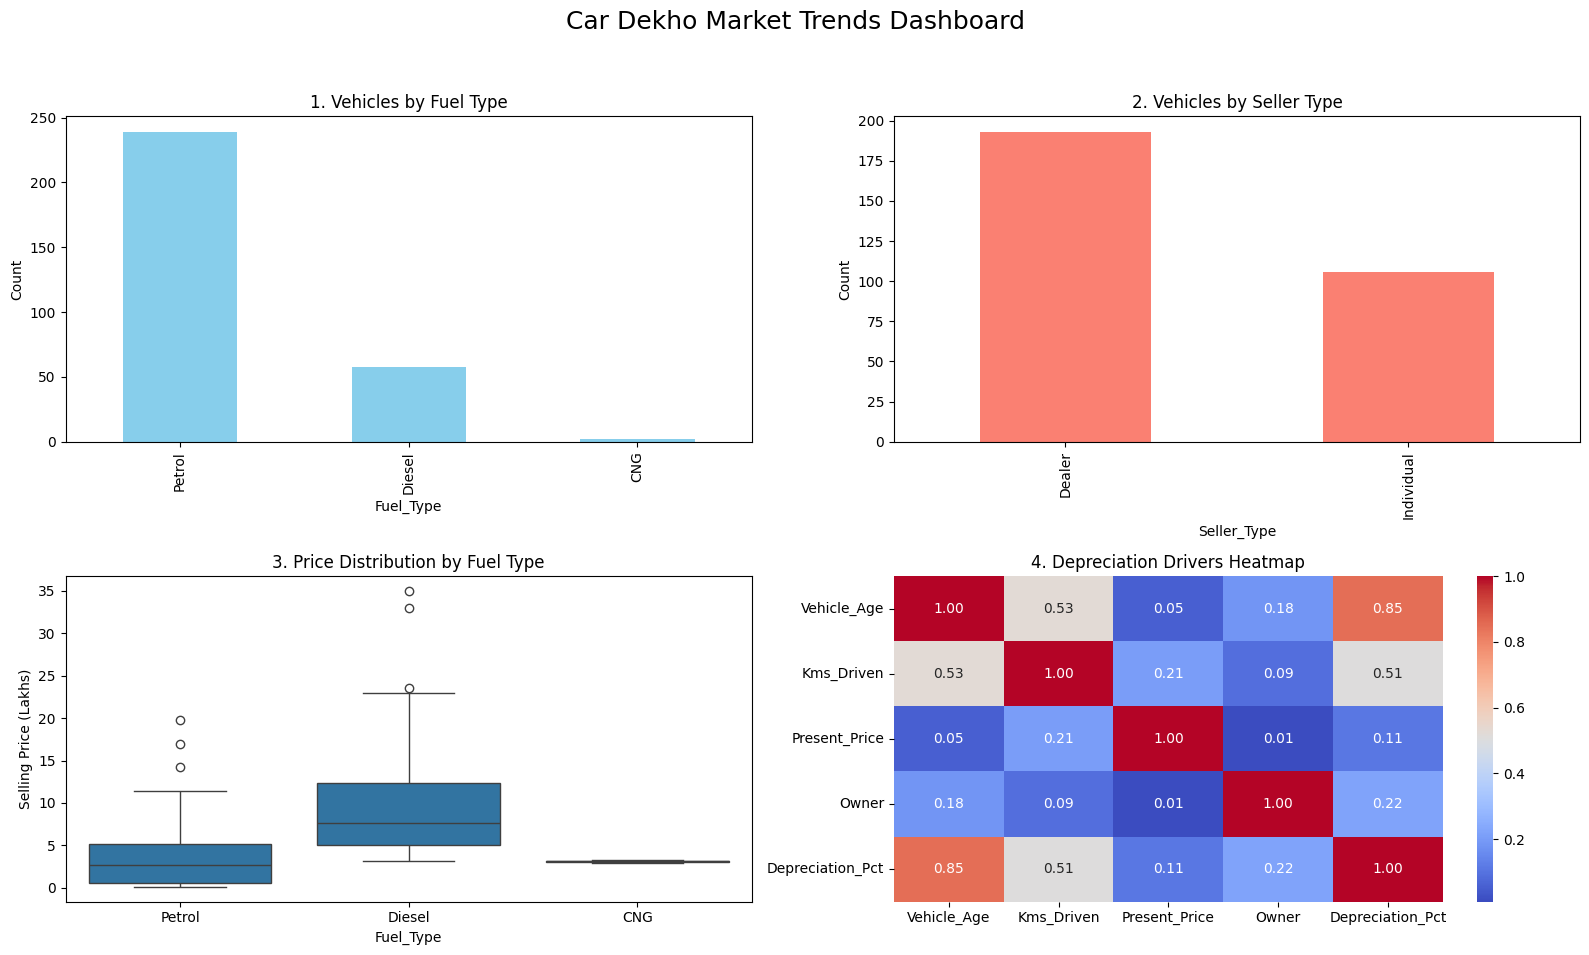

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Read uploaded file
df = pd.read_csv(
    "1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv"
)

# Clean duplicates
df = df.drop_duplicates().copy()

# Feature engineering
df["Vehicle_Age"] = 2018 - df["Year"]
df["Depreciation_Abs"] = df["Present_Price"] - df["Selling_Price"]
df["Depreciation_Pct"] = (df["Depreciation_Abs"] / df["Present_Price"]) * 100
df["Brand"] = df["Car_Name"].apply(lambda x: str(x).split()[0].lower())

# Dashboard Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Car Dekho Market Trends Dashboard", fontsize=18)

# Chart 1: Vehicles by Fuel Type
df["Fuel_Type"].value_counts().plot(kind="bar", ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("1. Vehicles by Fuel Type", fontsize=12)
axes[0, 0].set_ylabel("Count")

# Chart 2: Vehicles by Seller Type
df["Seller_Type"].value_counts().plot(
    kind="bar", ax=axes[0, 1], color="salmon"
)
axes[0, 1].set_title("2. Vehicles by Seller Type", fontsize=12)
axes[0, 1].set_ylabel("Count")

# Chart 3: Price Distribution by Fuel Type
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df, ax=axes[1, 0])
axes[1, 0].set_title("3. Price Distribution by Fuel Type", fontsize=12)
axes[1, 0].set_ylabel("Selling Price (Lakhs)")

# Chart 4: Correlation Heatmap
sns.heatmap(
    df[
        [
            "Vehicle_Age",
            "Kms_Driven",
            "Present_Price",
            "Owner",
            "Depreciation_Pct",
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    ax=axes[1, 1],
)
axes[1, 1].set_title("4. Depreciation Drivers Heatmap", fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()